# VisualAD 单张图推理

这个 notebook 按项目真实的测试流程重写，默认使用你 finetune 后的 bottle-cap checkpoint 对单张图片做推理，并输出：

- 图像级 `anomaly score`
- `正常 / 异常` 判定结果
- 异常热力图
- 映射回原图后的异常区域标注

与项目保持一致的关键点：

1. backbone、`image_size`、`features_list` 都从 checkpoint 读取。
2. 图像级分类分数使用项目里的 `reduce_anomaly_map(..., mode='topk_mean')`。
3. 默认分类阈值使用项目分析代码里的 `0.0`。
4. 输入图的归一化方式与训练 / 测试一致，使用 CLIP 的 mean / std。
5. 与原项目不同的唯一空间预处理改动，是先把原图短边 padding 到正方形，再 resize 到模型需要的尺寸。

In [1]:
from pathlib import Path

PROJECT_ROOT = next(
    (
        candidate
        for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
        if (candidate / 'README.md').exists() and (candidate / 'VisualAD_lib').exists() and (candidate / 'weight').exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate the bottle_VisualAD project root from the current working directory.')

# 按需修改这两个路径。
CHECKPOINT_PATH = PROJECT_ROOT / 'runs/bottle_positive_only/best_checkpoint.pth'
IMAGE_PATH = PROJECT_ROOT / 'own_datasets/90g/label/Image015.PNG'

# 运行参数。
REQUESTED_DEVICE = 'cuda:14'   # 'auto' / 'cpu' / 'cuda:0'
SIGMA = 4
DECISION_THRESHOLD = 0.0
PIXEL_THRESHOLD = 0.55
MIN_REGION_AREA = 80
SHOW_VISUALIZATION = True

assert PROJECT_ROOT.exists(), f'Project root not found: {PROJECT_ROOT}'
assert CHECKPOINT_PATH.exists(), f'Checkpoint not found: {CHECKPOINT_PATH}'
assert IMAGE_PATH.exists(), f'Image not found: {IMAGE_PATH}'

CHECKPOINT_PATH

PosixPath('/raid/yusq_lab/c12332451/mjz/bottle_VisualAD/runs/bottle_positive_only/best_checkpoint.pth')

In [2]:
import inspect
import sys
from types import SimpleNamespace

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from PIL import Image, ImageOps
from scipy.ndimage import gaussian_filter
from torchvision.transforms import InterpolationMode, Normalize, ToTensor

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import VisualAD_lib
from utils.anomaly_detection import generate_anomaly_map_from_tokens
from utils.feature_transform import create_feature_transform
from utils.scoring import DEFAULT_TOPK_RATIO, reduce_anomaly_map
from VisualAD_lib.constants import OPENAI_DATASET_MEAN, OPENAI_DATASET_STD


def resolve_device(requested_device='auto'):
    if requested_device == 'auto':
        return 'cuda:0' if torch.cuda.is_available() else 'cpu'
    return requested_device


def ensure_real_checkpoint(path: Path):
    prefix = path.read_bytes()[:128]
    if prefix.startswith(b'version https://git-lfs.github.com/spec/v1'):
        raise RuntimeError(
            '当前 checkpoint 仍然是 Git LFS pointer，不是真实权重。请先执行 `git lfs pull`，或者把真实的 CLIP.pth 放到这个路径。'
        )


def torch_load_compat(path, map_location='cpu'):
    signature = inspect.signature(torch.load)
    if 'weights_only' in signature.parameters:
        return torch.load(path, map_location=map_location, weights_only=False)
    return torch.load(path, map_location=map_location)


def clip_mean_fill_rgb():
    return tuple(int(round(channel * 255)) for channel in OPENAI_DATASET_MEAN)


def pad_short_side_to_square(image: Image.Image, fill_rgb=None):
    if fill_rgb is None:
        fill_rgb = clip_mean_fill_rgb()

    width, height = image.size
    side = max(width, height)
    pad_left = (side - width) // 2
    pad_top = (side - height) // 2
    pad_right = side - width - pad_left
    pad_bottom = side - height - pad_top

    padded = ImageOps.expand(
        image,
        border=(pad_left, pad_top, pad_right, pad_bottom),
        fill=fill_rgb,
    )

    pad_info = {
        'left': pad_left,
        'top': pad_top,
        'right': pad_right,
        'bottom': pad_bottom,
        'square_size': side,
    }
    return padded, pad_info


def prepare_image_like_project(image_path: Path, image_size: int):
    image_pil = Image.open(image_path).convert('RGB')

    padded_pil, pad_info = pad_short_side_to_square(image_pil, fill_rgb=clip_mean_fill_rgb())
    resized_pil = TF.resize(padded_pil, [image_size, image_size], interpolation=InterpolationMode.BICUBIC)

    tensor = ToTensor()(resized_pil)
    tensor = Normalize(OPENAI_DATASET_MEAN, OPENAI_DATASET_STD)(tensor)

    return {
        'original_pil': image_pil,
        'padded_pil': padded_pil,
        'resized_pil': resized_pil,
        'input_tensor': tensor,
        'pad_info': pad_info,
    }


def load_visualad_bundle(checkpoint_path: Path, requested_device='auto'):
    ensure_real_checkpoint(checkpoint_path)
    device = resolve_device(requested_device)

    checkpoint = torch_load_compat(str(checkpoint_path), map_location=device)
    backbone = checkpoint.get('backbone', 'ViT-L/14@336px')
    image_size = int(checkpoint.get('image_size', 518))
    features_list = checkpoint.get('features_list', [6, 12, 18, 24])
    finetune_info = checkpoint.get('finetune_info', {})

    model, _ = VisualAD_lib.load(backbone, device=device)
    model.eval()
    model.to(device)

    feature_dim = model.visual.embed_dim
    model.visual.anomaly_token.data = checkpoint['anomaly_token'].to(device)
    model.visual.normal_token.data = checkpoint['normal_token'].to(device)

    layer_transforms = nn.ModuleDict()
    if 'layer_transforms' in checkpoint:
        for layer_name, state_dict in checkpoint['layer_transforms'].items():
            hidden_dim = state_dict['mlp.0.weight'].shape[0]
            layer_transforms[layer_name] = create_feature_transform(
                transform_type='mlp',
                input_dim=feature_dim,
                hidden_dim=hidden_dim,
                output_dim=feature_dim,
                dropout=0.0,
            ).to(device)
            layer_transforms[layer_name].load_state_dict(state_dict)
            layer_transforms[layer_name].eval()

    cross_attn = None
    if 'cross_attn' in checkpoint:
        from utils.spatial_cross_attention import build_layer_adaptive_cross_attention

        config = checkpoint.get('cross_attn_config', {})
        cross_attn = build_layer_adaptive_cross_attention(
            layers=features_list,
            embed_dim=feature_dim,
            num_anchors=config.get('num_anchors', 4),
            dropout=config.get('dropout', 0.1),
            res_scale_init=config.get('res_scale_init', 0.01),
        ).to(device)
        cross_attn.load_state_dict(checkpoint['cross_attn'])
        cross_attn.eval()

    return {
        'checkpoint': checkpoint,
        'finetune_info': finetune_info,
        'device': device,
        'model': model,
        'cross_attn': cross_attn,
        'layer_transforms': layer_transforms,
        'backbone': backbone,
        'image_size': image_size,
        'features_list': features_list,
    }


In [3]:
def normalize_map_for_display(anomaly_map: np.ndarray):
    anomaly_map = anomaly_map.astype(np.float32)
    amap_min = float(anomaly_map.min())
    amap_max = float(anomaly_map.max())
    if amap_max > amap_min:
        return (anomaly_map - amap_min) / (amap_max - amap_min)
    return np.zeros_like(anomaly_map, dtype=np.float32)


def restore_square_map_to_original(square_map: np.ndarray, original_size, pad_info):
    original_width, original_height = original_size
    square_size = int(pad_info['square_size'])

    square_map = square_map.astype(np.float32)
    square_map = cv2.resize(square_map, (square_size, square_size), interpolation=cv2.INTER_LINEAR)

    left = int(pad_info['left'])
    top = int(pad_info['top'])
    cropped_map = square_map[top:top + original_height, left:left + original_width]

    if cropped_map.shape != (original_height, original_width):
        cropped_map = cv2.resize(cropped_map, (original_width, original_height), interpolation=cv2.INTER_LINEAR)

    return cropped_map


def filter_small_regions(binary_mask: np.ndarray, min_region_area=80):
    binary_mask = binary_mask.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
    filtered = np.zeros_like(binary_mask)

    for label_idx in range(1, num_labels):
        area = int(stats[label_idx, cv2.CC_STAT_AREA])
        if area >= int(min_region_area):
            filtered[labels == label_idx] = 1

    return filtered.astype(bool)


def build_localization_mask(normalized_map: np.ndarray, pixel_threshold=0.55, min_region_area=80):
    kernel = np.ones((3, 3), dtype=np.uint8)

    binary_mask = (normalized_map >= float(pixel_threshold)).astype(np.uint8)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
    binary_mask = filter_small_regions(binary_mask, min_region_area=min_region_area)

    if binary_mask.any():
        return binary_mask, float(pixel_threshold)

    flat = normalized_map.reshape(-1)
    k = max(1, int(np.ceil(flat.size * 0.01)))
    fallback_threshold = float(np.partition(flat, -k)[-k])
    fallback_mask = (normalized_map >= fallback_threshold).astype(np.uint8)
    fallback_mask = cv2.morphologyEx(fallback_mask, cv2.MORPH_OPEN, kernel)
    fallback_mask = cv2.morphologyEx(fallback_mask, cv2.MORPH_CLOSE, kernel)
    fallback_mask = filter_small_regions(fallback_mask, min_region_area=max(16, min_region_area // 2))
    return fallback_mask, fallback_threshold


def make_heatmap_overlay(image_np: np.ndarray, normalized_map: np.ndarray, alpha=0.45):
    heatmap_uint8 = np.clip(normalized_map * 255.0, 0, 255).astype(np.uint8)
    heatmap_bgr = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(heatmap_rgb, alpha, image_np, 1 - alpha, 0)
    return heatmap_rgb, overlay


def draw_localization_on_image(image_np: np.ndarray, binary_mask: np.ndarray):
    vis_image = image_np.copy()
    mask_uint8 = (binary_mask.astype(np.uint8) * 255)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        fill_layer = np.zeros_like(vis_image)
        cv2.drawContours(fill_layer, contours, -1, (255, 0, 0), thickness=cv2.FILLED)
        vis_image = cv2.addWeighted(fill_layer, 0.22, vis_image, 0.78, 0)
        cv2.drawContours(vis_image, contours, -1, (255, 0, 0), thickness=2)

    return vis_image, contours


def infer_single_image(
    image_path: Path,
    bundle,
    sigma=4,
    decision_threshold=0.0,
    pixel_threshold=0.55,
    min_region_area=80,
):
    prepared = prepare_image_like_project(image_path, bundle['image_size'])
    image_tensor = prepared['input_tensor'].unsqueeze(0).to(bundle['device'])

    model = bundle['model']
    cross_attn = bundle['cross_attn']
    layer_transforms = bundle['layer_transforms']
    features_list = bundle['features_list']
    image_size = bundle['image_size']

    with torch.no_grad():
        vision_output = model.encode_image(image_tensor, features_list)
        anomaly_features = vision_output['anomaly_features']
        normal_features = vision_output['normal_features']
        patch_tokens = vision_output['patch_tokens']
        patch_start_idx = vision_output['patch_start_idx']

        patch_features_list = [patch_token[:, patch_start_idx:, :] for patch_token in patch_tokens]
        if cross_attn is not None:
            adapted_list = cross_attn(anomaly_features, normal_features, patch_features_list, features_list)
            anomaly_features_list = [item['anomaly'] for item in adapted_list]
            normal_features_list = [item['normal'] for item in adapted_list]
        else:
            anomaly_features_list = [anomaly_features] * len(patch_tokens)
            normal_features_list = [normal_features] * len(patch_tokens)

        anomaly_map_list = []
        for layer_idx, patch_feature in enumerate(patch_tokens):
            anomaly_feat_norm = F.normalize(anomaly_features_list[layer_idx], dim=1, eps=1e-8)
            normal_feat_norm = F.normalize(normal_features_list[layer_idx], dim=1, eps=1e-8)

            transform_key = f"layer_{features_list[layer_idx]}"
            if transform_key in layer_transforms:
                batch_size, num_patches, feat_dim = patch_feature.shape
                patch_feature = layer_transforms[transform_key](patch_feature.view(-1, feat_dim)).view(batch_size, num_patches, feat_dim)

            anomaly_map = generate_anomaly_map_from_tokens(
                anomaly_feat_norm,
                normal_feat_norm,
                patch_feature[:, patch_start_idx:, :],
                image_size,
            )
            anomaly_map_list.append(anomaly_map)

        fused_square_map = torch.stack(anomaly_map_list).sum(dim=0).cpu()
        filtered_square_map = gaussian_filter(fused_square_map[0].numpy(), sigma=sigma)
        filtered_square_map_tensor = torch.from_numpy(filtered_square_map).unsqueeze(0)

        score = float(
            reduce_anomaly_map(
                filtered_square_map_tensor,
                mode='topk_mean',
                topk_ratio=DEFAULT_TOPK_RATIO,
            ).item()
        )
        probability = float(torch.sigmoid(torch.tensor(score)).item())
        pred_is_anomaly = score >= float(decision_threshold)

    original_image_np = np.array(prepared['original_pil'])
    original_size_map = restore_square_map_to_original(
        filtered_square_map,
        prepared['original_pil'].size,
        prepared['pad_info'],
    )
    normalized_original_map = normalize_map_for_display(original_size_map)
    heatmap_rgb, heatmap_overlay = make_heatmap_overlay(original_image_np, normalized_original_map)

    if pred_is_anomaly:
        binary_mask, effective_pixel_threshold = build_localization_mask(
            normalized_original_map,
            pixel_threshold=pixel_threshold,
            min_region_area=min_region_area,
        )
        localized_image, contours = draw_localization_on_image(original_image_np, binary_mask)
    else:
        binary_mask = np.zeros_like(normalized_original_map, dtype=bool)
        effective_pixel_threshold = float(pixel_threshold)
        localized_image = original_image_np.copy()
        contours = []

    return {
        'prediction_label': 'anomaly' if pred_is_anomaly else 'normal',
        'prediction_label_zh': '异常' if pred_is_anomaly else '正常',
        'pred_is_anomaly': pred_is_anomaly,
        'score': score,
        'probability': probability,
        'decision_threshold': float(decision_threshold),
        'pixel_threshold': effective_pixel_threshold,
        'num_regions': len(contours),
        'original_pil': prepared['original_pil'],
        'padded_pil': prepared['padded_pil'],
        'resized_pil': prepared['resized_pil'],
        'square_map': filtered_square_map,
        'original_size_map': original_size_map,
        'normalized_original_map': normalized_original_map,
        'heatmap_rgb': heatmap_rgb,
        'heatmap_overlay': heatmap_overlay,
        'binary_mask': binary_mask,
        'localized_image': localized_image,
        'pad_info': prepared['pad_info'],
    }


In [4]:
bundle = load_visualad_bundle(CHECKPOINT_PATH, requested_device=REQUESTED_DEVICE)
finetune_info = bundle.get('finetune_info', {})
effective_sigma = finetune_info.get('sigma', SIGMA)
effective_decision_threshold = finetune_info.get('decision_threshold', DECISION_THRESHOLD)

print('Project root:', PROJECT_ROOT)
print('Checkpoint:', CHECKPOINT_PATH)
print('Input image:', IMAGE_PATH)
print('Device:', bundle['device'])
print('Backbone:', bundle['backbone'])
print('Image size from checkpoint:', bundle['image_size'])
print('Feature layers from checkpoint:', bundle['features_list'])
print('Normalization mean:', OPENAI_DATASET_MEAN)
print('Normalization std:', OPENAI_DATASET_STD)
print('Square padding fill RGB:', clip_mean_fill_rgb())
if finetune_info:
    print('Finetune task:', finetune_info.get('task', 'n/a'))
    print('Finetune epoch:', finetune_info.get('epoch', 'n/a'))
    print('Inference sigma from checkpoint:', effective_sigma)
    print('Decision threshold from checkpoint:', effective_decision_threshold)

result = infer_single_image(
    IMAGE_PATH,
    bundle,
    sigma=effective_sigma,
    decision_threshold=effective_decision_threshold,
    pixel_threshold=PIXEL_THRESHOLD,
    min_region_area=MIN_REGION_AREA,
)

print('\nInference summary')
print('Image-level prediction:', result['prediction_label_zh'])
print(f"Anomaly score: {result['score']:.6f}")
print(f"Sigmoid(score): {result['probability']:.6f}")
print(f"Decision threshold: {result['decision_threshold']:.6f}")
if result['pred_is_anomaly']:
    print(f"Localization threshold: {result['pixel_threshold']:.4f}")
    print(f"Localized anomaly regions: {result['num_regions']}")
else:
    print('No anomaly regions highlighted because the image is classified as normal.')

name ViT-L/14@336px
Project root: /raid/yusq_lab/c12332451/mjz/bottle_VisualAD
Checkpoint: /raid/yusq_lab/c12332451/mjz/bottle_VisualAD/runs/bottle_positive_only/best_checkpoint.pth
Input image: /raid/yusq_lab/c12332451/mjz/bottle_VisualAD/own_datasets/90g/label/Image015.PNG
Device: cuda:14
Backbone: ViT-L/14@336px
Image size from checkpoint: 518
Feature layers from checkpoint: [6, 12, 18, 24]
Normalization mean: (0.48145466, 0.4578275, 0.40821073)
Normalization std: (0.26862954, 0.26130258, 0.27577711)
Square padding fill RGB: (123, 117, 104)
Finetune task: bottle_positive_only_adaptation
Finetune epoch: 3
Inference sigma from checkpoint: 4.0
Decision threshold from checkpoint: 0.0

Inference summary
Image-level prediction: 异常
Anomaly score: 6.400769
Sigmoid(score): 0.998343
Decision threshold: 0.000000
Localization threshold: 0.5500
Localized anomaly regions: 10


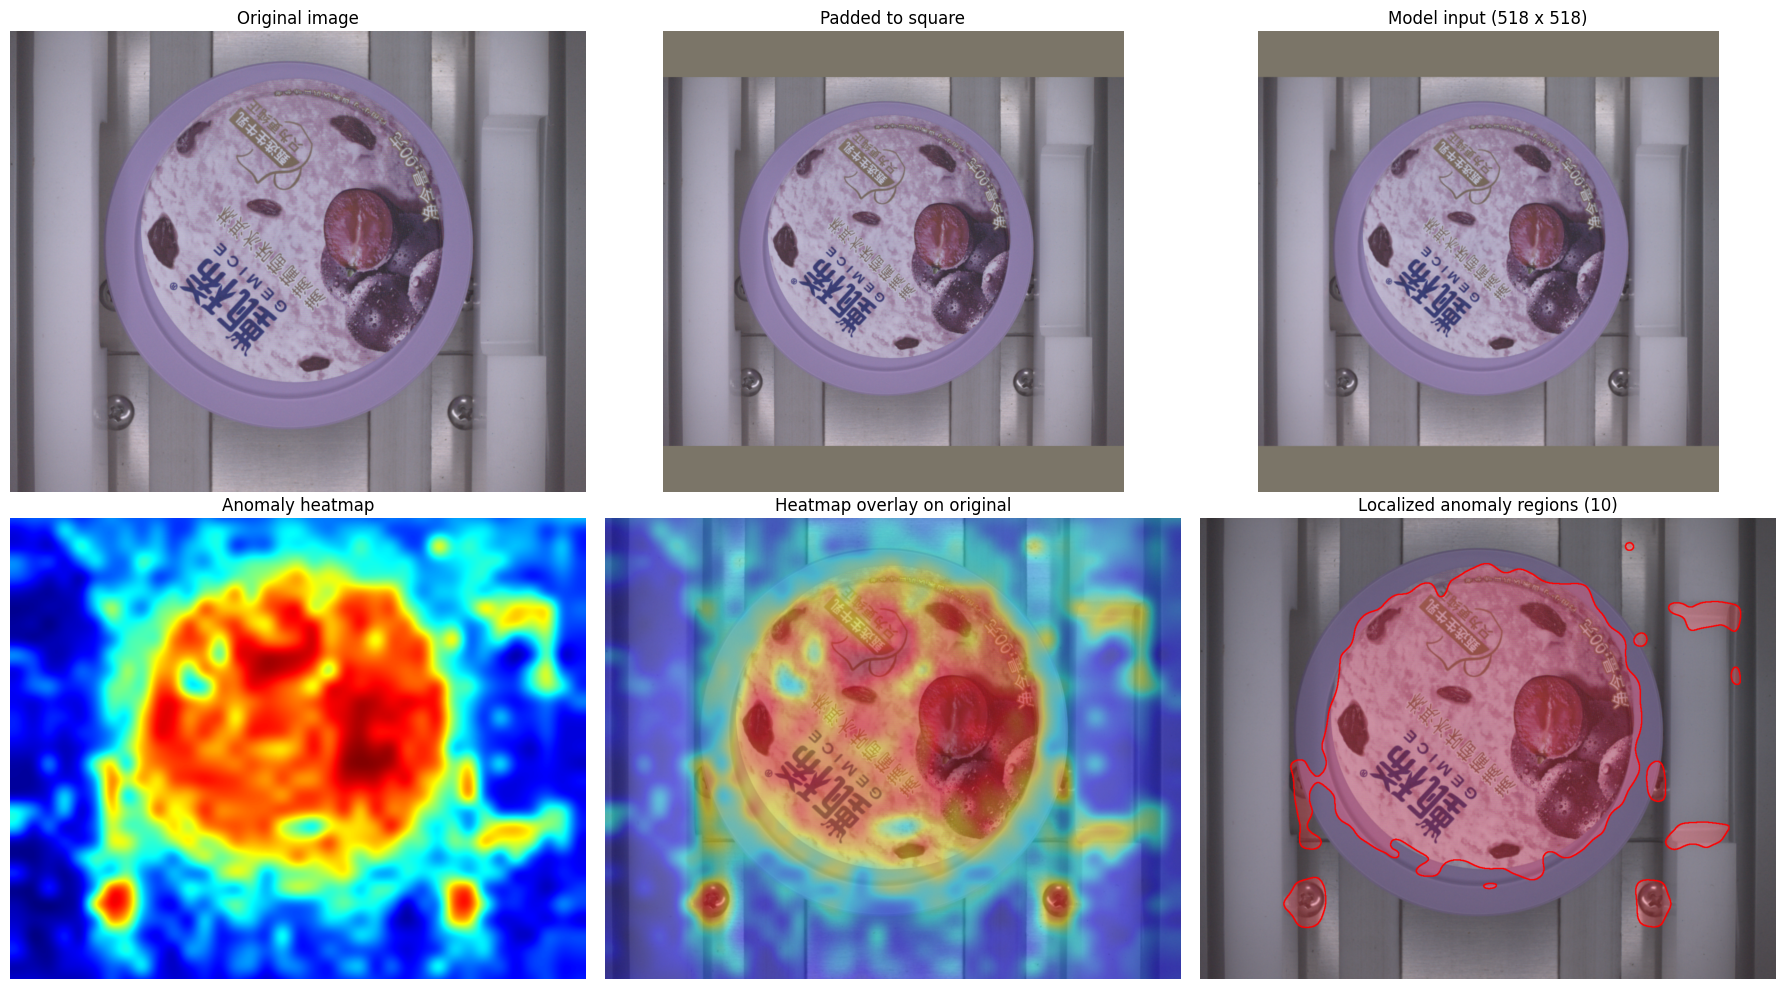

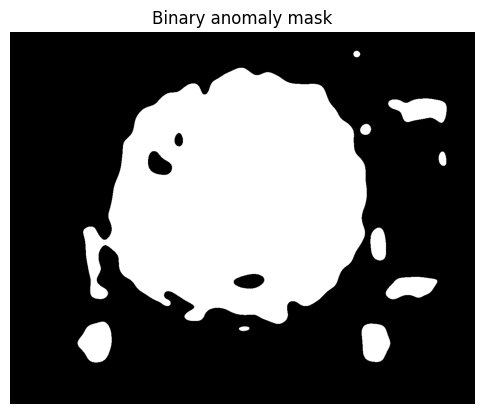

In [5]:
if SHOW_VISUALIZATION:
    original_np = np.array(result['original_pil'])
    padded_np = np.array(result['padded_pil'])
    resized_np = np.array(result['resized_pil'])
    heatmap_rgb = result['heatmap_rgb']
    heatmap_overlay = result['heatmap_overlay']
    binary_mask = result['binary_mask']
    localized_image = result['localized_image']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].imshow(original_np)
    axes[0, 0].set_title('Original image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(padded_np)
    axes[0, 1].set_title('Padded to square')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(resized_np)
    axes[0, 2].set_title(f"Model input ({bundle['image_size']} x {bundle['image_size']})")
    axes[0, 2].axis('off')

    axes[1, 0].imshow(heatmap_rgb)
    axes[1, 0].set_title('Anomaly heatmap')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(heatmap_overlay)
    axes[1, 1].set_title('Heatmap overlay on original')
    axes[1, 1].axis('off')

    axes[1, 2].imshow(localized_image)
    if result['pred_is_anomaly']:
        axes[1, 2].set_title(f"Localized anomaly regions ({result['num_regions']})")
    else:
        axes[1, 2].set_title('Localized result: normal')
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

    if result['pred_is_anomaly']:
        plt.figure(figsize=(6, 6))
        plt.imshow(binary_mask, cmap='gray')
        plt.title('Binary anomaly mask')
        plt.axis('off')
        plt.show()